In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm.auto import tqdm  # progress bars
import shutil


# ============================
# Domain and randomized global minimum (SHIFT)
# ============================
BOUNDS = [-6.0, 6.0]           # 6x6 domain
rng = np.random.default_rng()  # new seed each run -> new SHIFT each run

def sample_shift(bounds, margin=0.8):
    low, high = bounds
    return np.array([
        rng.uniform(low + margin, high - margin),
        rng.uniform(low + margin, high - margin)
    ], dtype=float)

SHIFT = sample_shift(BOUNDS, margin=0.8)  # random global minimum every run

# ============================
# Shifted Rastrigin objective (sinusoidal tiles)
# ============================
def rastrigin_shifted(X, A=10.0, noise=0.0, div=2):
    Z = X - SHIFT
    x, y = Z[:, 0], Z[:, 1]
    val = (x**2 - A*np.cos(2*np.pi*(x/div))) + (y**2 - A*np.cos(2*np.pi*(y/div))) + 2*A
    if noise > 0:
        val = val + np.random.normal(scale=noise, size=val.shape)
    return val

c:\Users\mauri\miniforge3\envs\dtu02452\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_grid = 600
x = np.linspace(BOUNDS[0], BOUNDS[1], n_grid)
y = np.linspace(BOUNDS[0], BOUNDS[1], n_grid)
Xg, Yg = np.meshgrid(x, y)
Zg = rastrigin_shifted(np.c_[Xg.ravel(), Yg.ravel()], A=10.0, noise=0.0).reshape(Xg.shape)

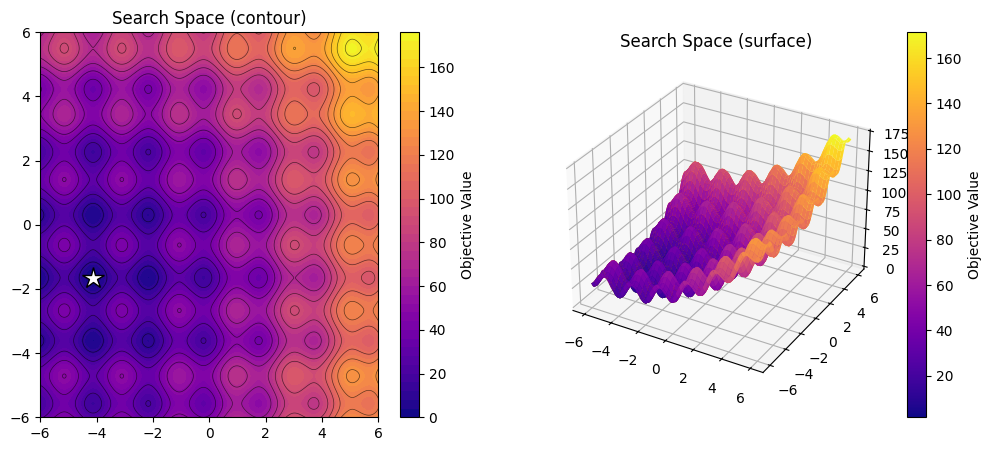

In [3]:
# contourplot and a surfplot sideby-side
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax1.contourf(Xg, Yg, Zg, levels=50, cmap='plasma')
ax1.contour(Xg, Yg, Zg, levels=20, colors='k', linewidths=0.5, alpha=0.6)
# Mark randomized global minimum with a star
ax1.plot(SHIFT[0], SHIFT[1], marker='*', color='white', markersize=16,
         markeredgecolor='black', label='Global minimum')
# show colorbar
plt.colorbar(ax1.contourf(Xg, Yg, Zg, levels=50, cmap='plasma'), ax=ax1, label='Objective Value')
ax1.set_title('Search Space (contour)') 
ax2.plot_surface(Xg, Yg, Zg, cmap='hot', edgecolor='none')
# show colorbar
plt.colorbar(ax2.plot_surface(Xg, Yg, Zg, cmap='plasma', edgecolor='none'), ax=ax2, label='Objective Value')

ax2.set_title('Search Space (surface)')
plt.show()

### Genetic Algorithm Configuration

This section defines the hyperparameters and control switches for the genetic algorithm (GA).

-   `use_elitism`: A boolean flag to enable or disable elitism. If `True`, the best `ELITE_K` individuals from the current generation are carried over to the next generation without modification.
-   `ELITE_K`: The number of elite individuals to preserve when `use_elitism` is active.

-   `POP_SIZE`: The total number of individuals in the population for each generation.
-   `GENS`: The total number of generations the algorithm will run.
-   `TOURN_SIZE`: The number of individuals randomly selected to compete in each tournament selection event. The winner of the tournament (the one with the lowest objective value) is selected for the next generation.
-   `CX_RATE`: The crossover rate, representing the probability that a pair of parents will undergo crossover to produce offspring.
-   `MUT_RATE`: The mutation rate, indicating the probability that an individual will be mutated.
-   `MUT_SCALE`: The standard deviation of the Gaussian noise added to an individual's genes during mutation. This controls the magnitude of the mutation.


### Core GA Functions

-   `init_population()`: Creates the initial population of `POP_SIZE` individuals. Each individual is a 2D point randomly sampled within the domain `BOUNDS`.
-   `select(pop, obj_vals)`: Implements tournament selection. For each spot in the new population, it randomly selects `TOURN_SIZE` individuals from the current population and chooses the one with the best (lowest) objective function value.
-   `crossover(parents)`: Performs arithmetic crossover on the population. It iterates through pairs of parents and, with a probability of `CX_RATE`, creates two new offspring by taking a weighted average of the parents' genes.
-   `mutate(p)`: Applies mutation to each individual in the population with a probability of `MUT_RATE`. Mutation involves adding random noise from a normal distribution (with scale `MUT_SCALE`) to the individual's genes. The mutated values are clipped to stay within the domain `BOUNDS`.
-   `get_elites(pop, obj_vals, k)`: Identifies and returns the top `k` individuals from the population based on their objective function values. These are the "elites."

Animating generations:   0%|          | 0/180 [02:29<?, ?it/s]


Running GA Simulation: 100%|██████████| 180/180 [00:00<00:00, 187.75it/s]


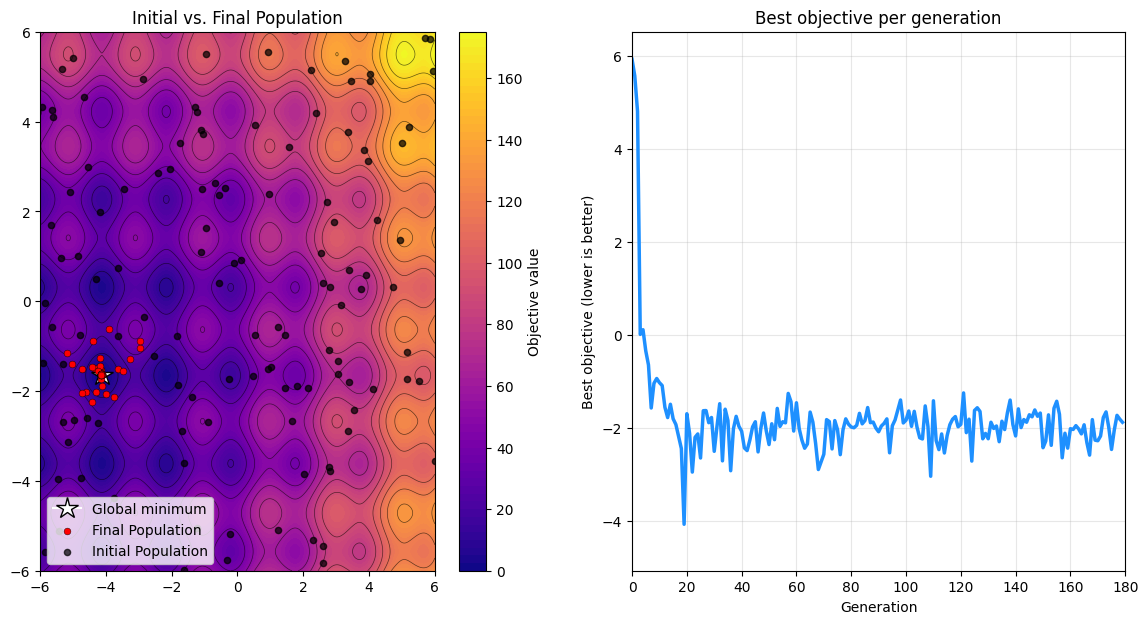

Randomized global minimum at: [-4.12557571 -1.65189124] | Elitism: False (K=3)


In [9]:
# ============================
# Dummy GA Functions for Student Implementation
# ============================

use_elitism = False   # <--- toggle elitism on/off
ELITE_K = 3          # number of elites to carry if use_elitism=True

# ============================
# Genetic Algorithm setup
# ============================
POP_SIZE   = 120
GENS       = 180
TOURN_SIZE = 2
CX_RATE    = 0.5
MUT_RATE   = 0.12
MUT_SCALE  = 0.45

def init_population(pop_size, bounds):
    """
    Initializes the population for the genetic algorithm.

    This function creates an initial population of `pop_size` individuals.
    Each individual is a 2D point (chromosome) randomly generated within
    the specified `bounds`.

    Args:
        pop_size (int): The number of individuals in the population.
        bounds (list or tuple): A list or tuple of two floats representing
                                the lower and upper bounds for the genes,
                                e.g., [-6.0, 6.0].

    Returns:
        np.ndarray: A NumPy array of shape (`pop_size`, 2) representing
                    the initial population.
    """
    # --- Student Implementation Here ---
    # Tip: You can use rng.uniform() to generate random numbers in a given range.
    # Consider generating the entire population array in a single call for efficiency.
    low, high = bounds
    # Generate pop_size individuals, each with 2 genes in [low, high]
    population = rng.uniform(low, high, size=(pop_size, 2))
    return population

def select(pop, obj_vals):
    """
    Selects individuals for the next generation using tournament selection.

    For each of the POP_SIZE spots in the next generation's population, 
    this function should:
    1. Randomly choose TOURN_SIZE individuals from the current population (`pop`).
        Hint: You can use `rng.choice` with `replace=False` to select without replacement.
    2. From this tournament group, select the single individual with the best 
       (lowest) objective function value (`obj_vals`).
    3. Add the selected winner to a list of chosen individuals.
    
    After repeating this process POP_SIZE times, the list of chosen 
    individuals becomes the parent pool for the next generation.

    Args:
        pop (np.ndarray): The current population of individuals. 
                          Shape: (POP_SIZE, num_dimensions).
        obj_vals (np.ndarray): The objective function values for each 
                               individual in the population. 
                               Shape: (POP_SIZE,).

    Returns:
        np.ndarray: The selected parents for the next generation.
                    Shape: (POP_SIZE, num_dimensions).
    """
    # --- Student Implementation Here ---
    selected = []
    for _ in range(POP_SIZE):
        # Randomly choose TOURN_SIZE individuals
        idxs = rng.choice(len(pop), size=TOURN_SIZE, replace=False)
        # Select the one with the lowest objective value
        best_idx = idxs[np.argmin(obj_vals[idxs])]
        selected.append(pop[best_idx])
    return np.array(selected)

def crossover(parents):
    """
    Performs crossover on the selected parents to produce offspring.
    Hint: Init kids by copying parents, then modify in-place.
    This function should iterate through the `parents` array in pairs.
    For each pair of parents, it should:
    1. Generate a random number. If this number is less than CX_RATE, 
       perform crossover to create two new offspring.
       Hint: You can use `rng.random()` to generate a random float in [0.0, 1.0).
    2. Crossover consists of creating two new individuals by taking a 
       weighted average of the parents' genes. The weights can be randomly 
       chosen for each gene.
    3. If crossover is not performed (the random number is greater than or 
       equal to CX_RATE), the offspring are simply copies of the parents.

    Args:
        parents (np.ndarray): The selected parents for the next generation.
                              Shape: (POP_SIZE, num_dimensions).

    Returns:
        np.ndarray: The offspring population after crossover.
                    Shape: (POP_SIZE, num_dimensions).
    """
    # --- Student Implementation Here ---
    offspring = parents.copy()
    for i in range(0, POP_SIZE, 2):
        if i + 1 >= POP_SIZE:
            break  # Odd population size: skip last if no pair
        if rng.random() < CX_RATE:
            # Random weights for each gene (shape: (2,))
            w = rng.uniform(0, 1, size=2)
            # Arithmetic crossover
            child1 = w * parents[i] + (1 - w) * parents[i + 1]
            child2 = w * parents[i + 1] + (1 - w) * parents[i]
            offspring[i] = child1
            offspring[i + 1] = child2
    return offspring

def mutate(p):
    """
    Applies mutation to individuals in the population.

    This function should iterate through each individual in the population `p`.
    For each individual, it should:
    1. Generate a random number. If this number is less than MUT_RATE, 
       apply mutation.
    2. Mutation consists of adding a random value to each gene (dimension)
       of the individual. This random value should be drawn from a normal
       distribution with a mean of 0 and a standard deviation of MUT_SCALE.
    3. After mutation, ensure that all gene values remain within the
       predefined BOUNDS by clipping them.

    Args:
        p (np.ndarray): The population to be mutated.
                        Shape: (POP_SIZE, num_dimensions).

    Returns:
        np.ndarray: The mutated population.
                    Shape: (POP_SIZE, num_dimensions).
    """
    # --- Student Implementation Here ---
    mutated = p.copy()
    for i in range(mutated.shape[0]):
        if rng.random() < MUT_RATE:
            # Add Gaussian noise to each gene
            mutation = rng.normal(0, MUT_SCALE, size=mutated.shape[1])
            mutated[i] += mutation
            # Clip to bounds
            mutated[i] = np.clip(mutated[i], BOUNDS[0], BOUNDS[1])
    return mutated

def get_elites(pop, obj_vals, k):
    """
    Identifies and returns the top 'k' elite individuals from the population.

    This function should:
    1. Find the indices of the 'k' individuals with the lowest objective
       function values (`obj_vals`).
    2. Use these indices to select the corresponding individuals from the
       population (`pop`).

    Args:
        pop (np.ndarray): The current population.
                          Shape: (POP_SIZE, num_dimensions).
        obj_vals (np.ndarray): The objective values for the population.
                               Shape: (POP_SIZE,).
        k (int): The number of elite individuals to select.

    Returns:
        np.ndarray: An array containing the top 'k' elite individuals.
                    Shape: (k, num_dimensions).
    """
    # --- Student Implementation Here ---
    elite_indices = np.argsort(obj_vals)[:k]
    elites = pop[elite_indices]
    return elites

# Initialize
pop = init_population(POP_SIZE, BOUNDS)

# ============================
# Visualization (high quality)
# ============================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# High-res, crisp contours (no noise in background)
n_grid = 600
x = np.linspace(BOUNDS[0], BOUNDS[1], n_grid)
y = np.linspace(BOUNDS[0], BOUNDS[1], n_grid)
Xg, Yg = np.meshgrid(x, y)
Zg = rastrigin_shifted(np.c_[Xg.ravel(), Yg.ravel()], A=10.0, noise=0.0).reshape(Xg.shape)

cont_f = ax1.contourf(Xg, Yg, Zg, levels=80, cmap='plasma')
ax1.contour(Xg, Yg, Zg, levels=20, colors='k', linewidths=0.5, alpha=0.6)
cbar = fig.colorbar(cont_f, ax=ax1)
cbar.set_label('Objective value')

# Mark randomized global minimum with a star
ax1.plot(SHIFT[0], SHIFT[1], marker='*', color='white', markersize=16,
         markeredgecolor='black', label='Global minimum')

# Population scatter
scat = ax1.scatter(pop[:, 0], pop[:, 1], c='red', s=24, edgecolors='black', linewidths=0.3, zorder=5)

ax1.legend(loc='upper left')
ax1.set_xlim(BOUNDS); ax1.set_ylim(BOUNDS)
ax1.set_title('Population on sinusoidal landscape (shifted Rastrigin)')

# Best objective plot
best_obj_history = []
line, = ax2.plot([], [], color='dodgerblue', lw=2.5)
ax2.set_xlim(0, GENS)
ax2.set_ylim(0, None)
ax2.set_xlabel('Generation')
ax2.set_ylabel('Best objective (lower is better)')
ax2.set_title('Best objective per generation')
ax2.grid(True, alpha=0.3)

# ============================
# tqdm progress bar
# ============================
pbar = tqdm(total=GENS, desc='Animating generations', leave=True)

ffmpeg_path = shutil.which('ffmpeg')
if ffmpeg_path is not None:
    print("ffmpeg found at:", ffmpeg_path)
    print("Generating animation with elitism =", use_elitism)
    def update(gen):
        global pop
        # Evaluate (noisy) objective for selection to keep dynamics interesting
        obj = rastrigin_shifted(pop, A=10.0, noise=0.8)
        best_obj_history.append(float(np.min(obj)))

        if use_elitism and ELITE_K > 0:
            elites = get_elites(pop, obj, ELITE_K)
        else:
            elites = None

        # Variation
        parents   = select(pop, obj)
        offspring = crossover(parents)
        offspring = mutate(offspring)

        if use_elitism and ELITE_K > 0:
            # Replace worst K in offspring with elites (ranked using noiseless eval)
            off_obj = rastrigin_shifted(offspring, A=10.0, noise=0.0)
            worst_idx = np.argsort(off_obj)[-ELITE_K:]
            offspring[worst_idx] = elites

        pop = offspring

        # Visual updates
        scat.set_offsets(pop)
        ax1.set_xlabel(f'Generation {gen+1}/{GENS}')
        xs = np.arange(len(best_obj_history))
        line.set_data(xs, best_obj_history)
        ax2.set_ylim(min(best_obj_history)-1, max(best_obj_history)*1.1)

        # Progress
        pbar.update(1)
        if gen + 1 == GENS:
            pbar.close()

        return scat, line

    anim = animation.FuncAnimation(
        fig, update, frames=GENS, interval=220, blit=True
    )

    # Save high-quality MP4 (requires ffmpeg) with tqdm on save
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=6, metadata=dict(artist='GA Sinusoidal Demo'), bitrate=6000)

    with tqdm(total=GENS, desc='Saving MP4', leave=True) as save_pbar:
        def _progress_callback(i, n):
            save_pbar.update(1)
        filename = f'./intelligent_systems_videos/ga_sinusoidal_random_shift_elitism_{use_elitism}.mp4'
        anim.save(filename, writer=writer, progress_callback=_progress_callback)

    plt.close(fig)
    print("Randomized global minimum at:", SHIFT, "| Elitism:", use_elitism, f"(K={ELITE_K})")
else:
    print("WARNING: ffmpeg not found. Skipping animation and generating static plots instead.")
    
    # Store initial population for plotting
    initial_pop = pop.copy()

    # Manually run the simulation loop
    for gen in tqdm(range(GENS), desc='Running GA Simulation'):
        obj = rastrigin_shifted(pop, A=10.0, noise=0.8)
        best_obj_history.append(float(np.min(obj)))

        elites = get_elites(pop, obj, ELITE_K) if use_elitism and ELITE_K > 0 else None

        parents   = select(pop, obj)
        offspring = crossover(parents)
        offspring = mutate(offspring)

        if use_elitism and ELITE_K > 0:
            off_obj = rastrigin_shifted(offspring, A=10.0, noise=0.0)
            worst_idx = np.argsort(off_obj)[-ELITE_K:]
            offspring[worst_idx] = elites
        
        pop = offspring

    # --- Generate Static Plots ---
    # Plot initial and final populations
    ax1.scatter(initial_pop[:, 0], initial_pop[:, 1], c='k', s=20, alpha=0.7, label='Initial Population', zorder=4)
    scat.set_offsets(pop) # Update scatter to final population
    scat.set_label('Final Population')
    ax1.set_title('Initial vs. Final Population')
    ax1.legend()

    # Plot objective history
    xs = np.arange(len(best_obj_history))
    line.set_data(xs, best_obj_history)
    ax2.set_ylim(min(best_obj_history)-1, max(best_obj_history)*1.1)
    ax2.figure.canvas.draw()
    plt.show()
    plt.close(fig)
    print("Randomized global minimum at:", SHIFT, "| Elitism:", use_elitism, f"(K={ELITE_K})")

### Reinforcement Learning in a Grid World

This section focuses on solving a navigation problem in a `GridWorld` environment using two classic temporal-difference (TD) learning algorithms: **Q-Learning** and **SARSA**. The agent's goal is to find the optimal path from a starting position to a goal position while avoiding obstacles.

---

#### 1. The `GridWorld` Environment

The `GridWorld` class defines the problem space.

-   **States**: The state is represented by the agent's `(row, column)` coordinates on the grid.
-   **Actions**: The agent can take one of four discrete actions, represented by integers:
    -   `0`: Move Up
    -   `1`: Move Right
    -   `2`: Move Down
    -   `3`: Move Left
-   **Rewards**: The environment provides a reward signal to guide the agent. A positive reward is given for reaching the goal, and a small negative penalty (cost) is applied for every step taken, encouraging efficiency.

---

#### 2. Core Concepts: Return and Q-Values

To make decisions, the agent needs a way to quantify how good a state or an action is.

##### Discounted Return (G_t)

The agent's goal is to maximize its total future reward. However, rewards received sooner are often more valuable than rewards received later. The **Discounted Return** formalizes this idea. It is the sum of all future rewards from a time step `t`, where each reward is "discounted" by a factor `γ` (gamma) for each step into the future.

**Formula:**
`G_t = R_{t+1} + γ * R_{t+2} + γ² * R_{t+3} + ...`

-   The **discount factor** `γ` is a value between 0 and 1.
-   If `γ = 0`, the agent is "myopic" and only cares about the immediate reward.
-   If `γ` is close to 1, the agent is "farsighted," valuing future rewards almost as much as immediate ones.

##### Q-Values (Action-Values)

While the return `G_t` is something calculated *after* an episode is over, the agent needs to *predict* the potential return to make decisions. This is the role of the **Q-value**.

The Q-value, `Q(s, a)`, represents the **expected discounted return** the agent can get if it starts in **state `s`**, takes **action `a`**, and then follows the best possible policy from that point on.

In simple terms, `Q(s, a)` answers the question:
> "What is the total future reward I can expect if I take action `a` from state `s`?"

-   **Q-Table**: For this grid world, we can store all Q-values in a table (a 3D NumPy array) where the dimensions are `(row, column, action)`. This table acts as a "cheat sheet" for the agent.
-   **Optimal Policy**: Once the Q-table is learned, the optimal action in any state `s` is simply the one with the highest Q-value: `argmax_a Q(s, a)`.

---

#### 3. Learning Algorithms

-   **Q-Learning (Off-Policy)**: Updates its Q-value for a state-action pair by considering the best possible action in the next state (`max_a' Q(s', a')`), regardless of what action is actually chosen next. This is an optimistic approach.

-   **SARSA (On-Policy)**: Updates its Q-value based on the action that is *actually* taken in the next step. Its update rule uses the tuple `(State, Action, Reward, next State, next Action)`. This makes it more conservative as it learns the value of the policy it is currently following, including its exploratory moves.

In [ ]:
import random, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import ListedColormap, BoundaryNorm


# ══════════════════════════════════════════════════════════
# 1 — Windy GridWorld (reward_type: 'step' or 'euclidean')
# ══════════════════════════════════════════════════════════
class GridWorld:
    def __init__(self, size=10, num_blocks=15, wind_prob=0.0,
                 max_steps=None, seed=None, reward_type='step'):
        '''
        Windy GridWorld environment.
        Args:
            size (int): Grid size (size x size).
            num_blocks (int): Number of obstacles.
            wind_prob (float): Probability of wind affecting movement.
            max_steps (int): Maximum steps per episode.
            seed (int): Random seed for reproducibility.
            reward_type (str): 'step' for fixed step penalty, 'euclidean' for
                               distance-based penalty.

        '''
        self.size, self.num_blocks, self.wind = size, num_blocks, wind_prob
        self.max_steps = max_steps or num_blocks * 4
        self.reward_type = reward_type
        if seed is not None:
            random.seed(seed); np.random.seed(seed)
        self.blocks = set()
        self.start = (0, 0)                     # red
        self.goal  = (self.size-1, self.size-1) # green
        self.agent, self.steps = self.start, 0
        while len(self.blocks) < self.num_blocks:
            self.blocks.add(self._rand_cell({self.start, self.goal}.union(self.blocks)))
        self.reset()

    # ------------------------------------------------------
    def reset(self):
        '''
        Resets the environment to the initial state.
        Returns:
            tuple: The starting position of the agent.
        '''
        self.start = (0, 0)                     # red
        self.goal  = (self.size-1, self.size-1) # green
        self.agent, self.steps = self.start, 0
        return self.agent

    # ------------------------------------------------------
    def step(self, a):
        '''
        Takes an action in the environment.
        Args:
            a (int): Action to take (0=up, 1=right, 2=down, 3=left).
        Returns:
            next_state (tuple): The new position of the agent.
            reward (float): The reward received after taking the action.
            done (bool): Whether the episode has ended (reached goal or max steps).
        '''
        self.steps += 1
        if random.random() < self.wind:
            a = random.choice([x for x in range(2,4)])

        r, c = self.agent
        if   a == 0: r = max(r-1, 0)
        elif a == 1: c = min(c+1, self.size-1)
        elif a == 2: r = min(r+1, self.size-1)
        elif a == 3: c = max(c-1, 0)

        nxt = (r, c) if (r, c) not in self.blocks else self.agent
        self.agent = nxt
        done = nxt == self.goal or self.steps >= self.max_steps

        if self.reward_type == 'euclidean':
            gr, gc = self.goal
            dist   = np.hypot(gr - r, gc - c)/(self.max_steps)
            reward = 4.0 if nxt == self.goal else -dist
        else:  # 'step'
            reward = 4.0 if nxt == self.goal else -0.5
        return nxt, reward, done

    # ------------------------------------------------------
    def _rand_cell(self, exclude):
        while True:
            cell = (random.randrange(self.size), random.randrange(self.size))
            if cell not in exclude:
                return cell


# ══════════════════════════════════════════════════════════
# 2 — ε-greedy helpers
# ══════════════════════════════════════════════════════════
def eps_greedy(Q, s, eps):
    '''
    Epsilon-greedy action selection.
    With probability eps, selects a random action.
    Hint: Use random.random() to get a float in [0.0, 1.0). If it's < eps, pick random action.
    Otherwise, pick the action with the highest Q-value for state s.
    Args:
        Q (np.ndarray): The Q-table of shape (env.size, env.size, 4).
        s (tuple): The current state (row, col).
        eps (float): The probability of choosing a random action.
    Returns:
        int: The selected action (0=up, 1=right, 2=down, 3=left).
    '''
    if random.random() < eps:
        return random.randint(0, 3)
    else:
        return int(np.argmax(Q[s]))

def eps_linear(ep, total, start=1.0, end=0.01):
    '''
    Linearly decays epsilon from start to end.
    '''
    pass


def q_learning(env, episodes=1000, alpha=0.10, gamma=0.99):
    """
    Implements the Q-learning algorithm (an off-policy TD control method).

    This function learns a policy for an agent to navigate the environment by
    iteratively updating a Q-table, which estimates the value of taking a
    certain action in a certain state.

    Args:
        env (object): The environment object, which must have `reset()` and `step()` methods.
        episodes (int): The total number of episodes to train for.
        alpha (float): The learning rate, determining how much new information overrides old information.
        gamma (float): The discount factor, valuing future rewards.

    Returns:
        tuple: A tuple containing:
            - Q (np.ndarray): The learned Q-table of shape (env.size, env.size, 4).
            - rewards (list): A list of total rewards obtained in each episode.
            - eps_track (list): A list of epsilon values used in each episode.

    Implementation Steps:
    1.  Initialize the Q-table to all zeros.
    2.  Loop through the specified number of `episodes`.
    3.  In each episode, reset the environment to get the starting state `s`.
    4.  Loop until the episode is `done`:
        a. Choose an action `a` from state `s` using the `eps_greedy` policy.
        b. Perform the action `a` to get the next state `s2`, reward `r`, and `done` flag.
        c. Update the Q-table using the Q-learning rule:
           Q(s, a) <- Q(s, a) + alpha * (r + gamma * max_a'(Q(s2, a')) - Q(s, a))
           Hint: `np.max(Q[s2])` gives you the `max_a'(Q(s2, a'))` part.
           Hint: You can index the Q-table like this: `Q[s + (a,)]`.
        d. Update the current state: `s = s2`.
        e. Add the received reward `r` to the total for the episode.
    5.  After each episode, store the total reward and the epsilon value.
    """
    # --- Student Implementation Here ---
    pass

def sarsa(env, episodes=1000, alpha=0.10, gamma=0.99):
    """
    Implements the SARSA algorithm (an on-policy TD control method).

    SARSA (State-Action-Reward-State-Action) is similar to Q-learning but updates
    its Q-table based on the action that is actually taken in the next step,
    making it an on-policy method.

    Args:
        env (object): The environment object with `reset()` and `step()` methods.
        episodes (int): The total number of episodes to train for.
        alpha (float): The learning rate.
        gamma (float): The discount factor.

    Returns:
        tuple: A tuple containing:
            - Q (np.ndarray): The learned Q-table.
            - rewards (list): A list of total rewards per episode.
            - eps_track (list): A list of epsilon values per episode.

    Implementation Steps:
    1.  Initialize the Q-table to all zeros.
    2.  Loop through the specified number of `episodes`.
    3.  In each episode, reset the environment to get the starting state `s`.
    4.  Choose the first action `a` from state `s` using the `eps_greedy` policy.
    5.  Loop until the episode is `done`:
        a. Perform action `a` to get the next state `s2`, reward `r`, and `done` flag.
        b. Choose the *next* action `a2` from the *next* state `s2` using the `eps_greedy` policy.
        c. Update the Q-table using the SARSA rule:
           Q(s, a) <- Q(s, a) + alpha * (r + gamma * Q(s2, a2) - Q(s, a))
           Hint: The key difference from Q-learning is using `Q[s2 + (a2,)]` instead of `np.max(Q[s2])`.
        d. Update the state and action for the next iteration: `s = s2`, `a = a2`.
        e. Add the reward `r` to the episode's total.
    6.  After each episode, store the total reward and epsilon value.
    """
    # --- Student Implementation Here ---
    pass

# ══════════════════════════════════════════════════════════
# 4 — Evaluation & plotting helpers
# ══════════════════════════════════════════════════════════
def greedy_path(env, Q):
    '''
    Generates the greedy path from start to goal using the learned Q-table.
    Args:
        env (object): The environment object with `reset()` and `step()` methods.
        Q (np.ndarray): The learned Q-table of shape (env.size, env.size, 4).
    Returns:
        list: A list of (state, action) tuples representing the greedy path.
    '''
    path, s, done = [], env.reset(), False
    while not done:
        a = int(np.argmax(Q[s]))
        path.append((s, a))
        s, _, done = env.step(a)
    return path


from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np


def plot_grid_path(env, path):
    """
    Visualise GridWorld with:
      • red  = start
      • green = goal
      • black = obstacles
      • teal  = visited path
      • white = free cells
    Arrows show the greedy trajectory.
    """
    # ── 1. Build numeric grid ───────────────────────────────
    grid = np.ones((env.size, env.size))          # 1.00 → white background
    for r, c in env.blocks:       grid[r, c] = 0.30   # obstacles
    for (r, c), _ in path:        grid[r, c] = 0.60   # path
    grid[env.start]               = 0.95              # start
    grid[env.goal]                = 0.15              # goal

    # ── 2. Discrete colour map (order matters!) ─────────────
    cmap  = ListedColormap(['red',      # index-0 → 0.95
                            'black',    # index-1 → 0.15
                            'green',    # index-2 → 0.30
                            'teal',     # index-3 → 0.60
                            'white'])   # index-4 → 1.00
    bounds = [0, 0.2, 0.4, 0.7, 0.96, 1.01]
    norm   = BoundaryNorm(bounds, cmap.N)

    # ── 3. Draw the grid ───────────────────────────────────
    plt.figure(figsize=(8, 8))
    plt.pcolormesh(grid[::-1], cmap=cmap, norm=norm,
                   edgecolors='k', linewidth=2)
    plt.gca().invert_yaxis()
    plt.xticks(np.arange(env.size) + 0.5, labels=np.arange(env.size))
    plt.yticks(np.arange(env.size) + 0.5, labels=np.arange(env.size)[::-1])

    # ── 4. Overlay trajectory arrows ───────────────────────
    delta = {0: (0, 0.7), 1: (0.7, 0), 2: (0, -0.7), 3: (-0.7, 0)}
    ax = plt.gca()
    for (r, c), a in path:
        dx, dy = delta[a]
        ax.arrow(c + 0.5,
                 env.size - r - 0.5,   # flip y-axis
                 dx, dy,
                 head_width=0.25,
                 head_length=0.25,
                 fc='black', ec='black',
                 length_includes_head=True)

    plt.title('Grid: teal=start, red=goal, black=obstacles, green=path')
    plt.tight_layout()
    plt.axis('off')
    plt.show()



def plot_progress(rewards, epsilons, alg_name='Sarsa'):
    '''
    Plots training progress: rewards and epsilons over episodes.
    Args:
        rewards (list): List of rewards per episode.
        epsilons (list): List of epsilon values per episode.
        alg_name (str): Name of the algorithm for the title.
    '''
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(rewards,  color='steelblue',  label='Reward')
    ax2.plot(epsilons, color='firebrick', label='Epsilon')
    ax1.set_xlabel('Episode', fontsize=16)
    ax1.tick_params(axis='x', labelsize=16)
    ax1.set_ylabel('Reward',  color='steelblue', fontsize=16); ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=16)
    ax2.set_ylabel('Epsilon', color='firebrick', fontsize=16);  ax2.tick_params(axis='y', labelcolor='firebrick', labelsize=16)
    # ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.title('Training progress '+ alg_name)
    plt.tight_layout()
    plt.show()

def show_q_maps(Q):
    """
    Display one heat-map per action (Up, Right, Down, Left).
    Assumes Q.shape == (rows, cols, 4).
    """
    acts = ['Up', 'Right', 'Down', 'Left']
    fig, axes = plt.subplots(1, 4, figsize=(4*len(acts), 4))

    for i, ax in enumerate(axes):
        heat = Q[:, :, i]                     # slice for action i
        mesh = ax.pcolormesh(heat[::-1], cmap='plasma')
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(Q.shape[1]) + .5, labels=np.arange(Q.shape[1]))
        ax.set_yticks(np.arange(Q.shape[0]) + .5, labels=np.arange(Q.shape[0])[::-1])
        ax.set_title(f'{acts[i]} Q-values')
        fig.colorbar(mesh, ax=ax)

    plt.tight_layout()
    plt.show()


In [11]:
# ══════════════════════════════════════════════════════════
# 5 — Run
# ══════════════════════════════════════════════════════════
# if __name__ == '__main__':
env = GridWorld(num_blocks=25, wind_prob=0,
                reward_type='step')         # or 'euclidean'
# Execute Q-learning and plot the results

# Execute Sarsa and plot the results